In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  USER CONFIG
# ══════════════════════════════════════════════════════════════════════════════

NOISE_SCALE = 1.0          # noise amplitude (1.0 = realistic MicroBooNE noise)
NOISE_SEED  = 0            # random seed

DIRECTION   = (1, 1, 1)    # muon direction
MOMENTUM    = 1000.0       # kinetic energy in MeV

VOL = 1                    # which detector volume to plot

In [6]:
import sys
sys.path.append('../')

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from tools.geometry import generate_detector
from tools.simulation import DetectorSimulator
from tools.loader import build_deposit_data
from tools.particle_generator import generate_muon_track
from tools.noise import generate_noise
from tools.visualization import _extract_viz_params

cfg       = generate_detector('../config/cubic_wireplane_config.yaml')
simulator = DetectorSimulator(
    cfg,
    differentiable=True,
    n_segments=50_000,
    use_bucketed=True,
    max_active_buckets=1000,
    include_noise=False,
    include_electronics=False,
    include_track_hits=False,
    include_digitize=False,
    track_config=None,
)
simulator.warm_up()
sim_cfg = simulator.config

--- Creating DetectorSimulator ---
   Extracting parameters...
   Loading response kernels...
   Space charge effects: DISABLED
   Recombination model: emb
   Config: total_pad=50,000, response_chunk=50,000, num_s=16, K_wire=2, K_time=6
   Track labeling: DISABLED
   Readout: wire
   Volumes: 2 (iterate=scan)
--- DetectorSimulator Ready ---
Triggering JIT compilation...
JIT compilation finished (total_pad=50,000, iterate=scan).


In [7]:
track = generate_muon_track(
    start_position_mm=(0.0, 0.0, 0.0),
    direction=DIRECTION,
    kinetic_energy_mev=MOMENTUM,
    step_size_mm=0.1,
    track_id=1,
    #detector_bounds_mm=((-300, 300), (-300, 300), (-300, 300)),
)
deposits = build_deposit_data(
    track['position'], track['de'], track['dx'], sim_cfg,
    theta=track['theta'], phi=track['phi'],
    track_ids=track['track_id'],
)
print(f'Generated {len(track["de"]):,} deposits')

Generated 44,083 deposits


In [8]:
# ── Forward pass (no noise) — returns tuple of arrays, one per (vol, plane) ───
params       = simulator.default_sim_params
clean_tuple  = simulator.forward(params, deposits)
jax.block_until_ready(clean_tuple)

n_planes = sim_cfg.volumes[VOL].n_planes
plane_keys = [(v, p) for v in range(sim_cfg.n_volumes) for p in range(n_planes)]
clean = {k: np.asarray(a) for k, a in zip(plane_keys, clean_tuple)}

noise_dict   = generate_noise(sim_cfg, key=jax.random.PRNGKey(NOISE_SEED))

noisy = {}

for (v, p), arr in clean.items():
    n = noise_dict[(v, p)] * NOISE_SCALE
    if n.shape[0] < arr.shape[0]:
        n = jnp.pad(n, ((0, arr.shape[0] - n.shape[0]), (0, 0)))
    noisy[(v, p)] = np.asarray(arr + n)

signal_rms = float(np.sqrt(np.mean(np.concatenate([clean[(VOL, p)].ravel()**2 for p in range(n_planes)]))))
noise_rms  = float(np.sqrt(np.mean(np.concatenate([(noisy[(VOL,p)] - clean[(VOL,p)]).ravel()**2 for p in range(n_planes)]))))
print(f'Signal RMS: {signal_rms:.4f}  Noise RMS: {noise_rms:.4f}  SNR: {signal_rms/noise_rms:.2f}')
print("Signal max: {:.4f}  Noise max: {:.4f}".format(
    max(np.concatenate([clean[(VOL, p)].ravel() for p in range(n_planes)])),
    max(np.concatenate([(noisy[(VOL,p)] - clean[(VOL,p)]).ravel() for p in range(n_planes)])),
))

Signal RMS: 4.0834  Noise RMS: 1.7426  SNR: 2.34
Signal max: 255.6890  Noise max: 10.9199


In [9]:
# Print {key: rms} for each noise array
for (v, p), arr in clean.items():
    n = noisy[(v, p)] - arr
    arr_rms = float(np.sqrt(np.mean(arr.ravel()**2)))
    noise_rms = float(np.sqrt(np.mean(n.ravel()**2)))
    print(f'Plane (vol={v}, plane={p}): signal RMS={arr_rms:.4f}, noise RMS={noise_rms:.4f}, SNR={arr_rms/noise_rms:.2f}')

Plane (vol=0, plane=0): signal RMS=0.0000, noise RMS=1.7745, SNR=0.00
Plane (vol=0, plane=1): signal RMS=0.0000, noise RMS=1.7751, SNR=0.00
Plane (vol=0, plane=2): signal RMS=0.0000, noise RMS=1.6777, SNR=0.00
Plane (vol=1, plane=0): signal RMS=3.7673, noise RMS=1.7745, SNR=2.12
Plane (vol=1, plane=1): signal RMS=2.0025, noise RMS=1.7744, SNR=1.13
Plane (vol=1, plane=2): signal RMS=5.6409, noise RMS=1.6771, SNR=3.36


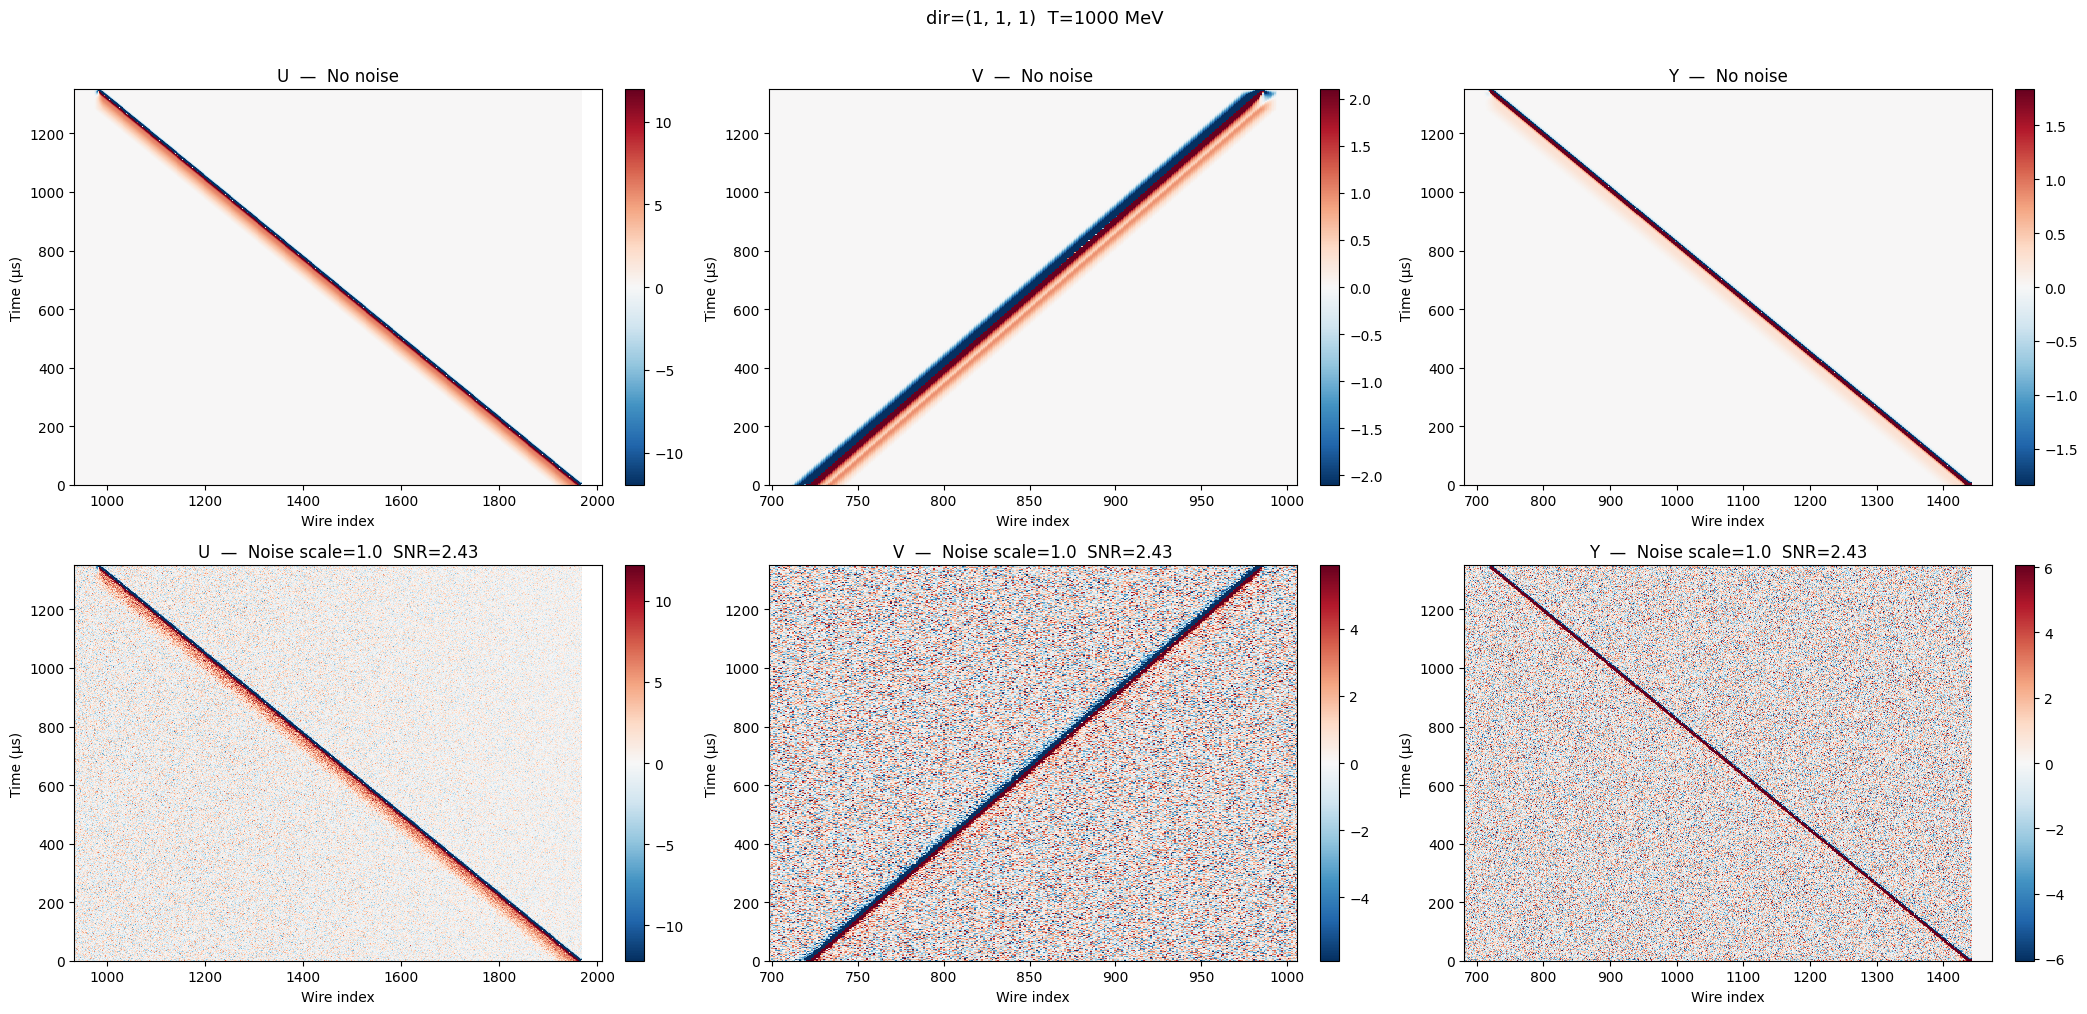

In [10]:
vp        = _extract_viz_params(sim_cfg)
time_step = vp['time_step_us']
max_time  = vp['num_time_steps'] * time_step
PLANE_LETTERS = {0: 'U', 1: 'V', 2: 'Y'}
MARGIN = 0.04

# ── Bounding box from clean signal ────────────────────────────────────────────
plane_xlim, plane_ylim = {}, {}
for p in range(n_planes):
    arr     = clean[(VOL, p)]
    mask    = arr != 0
    wire_nz = np.where(mask.any(axis=1))[0]
    time_nz = np.where(mask.any(axis=0))[0]
    if len(wire_nz) and len(time_nz):
        w0, w1 = float(wire_nz[0]),        float(wire_nz[-1] + 1)
        t0, t1 = float(time_nz[0]) * time_step, float(time_nz[-1] + 1) * time_step
        wx, tx = (w1 - w0) * MARGIN, (t1 - t0) * MARGIN
        plane_xlim[p] = (max(0.0, w0 - wx), w1 + wx)
        plane_ylim[p] = (max(0.0, t0 - tx), min(max_time, t1 + tx))
    else:
        plane_xlim[p] = (0, arr.shape[0])
        plane_ylim[p] = (0, max_time)

# ── 2-row × 3-col figure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, n_planes, figsize=(7 * n_planes, 10), facecolor='white')

rows = [
    (clean, 'No noise'),
    (noisy, f'Noise scale={NOISE_SCALE}  SNR={signal_rms/noise_rms:.2f}'),
]

for row_idx, (arrays, row_label) in enumerate(rows):
    for col_idx in range(n_planes):
        ax  = axes[row_idx, col_idx]
        arr = arrays[(VOL, col_idx)]

        # diverging cmap for induction (bipolar), sequential for collection
        has_neg  = arr.min() < 0
        cmap     = 'RdBu_r' if has_neg else 'viridis'
        vmax     = float(np.percentile(np.abs(arr), 99.5))
        vmin     = -vmax if has_neg else 0.0

        im = ax.imshow(
            arr.T, aspect='auto', origin='lower',
            extent=[0, arr.shape[0], 0, max_time],
            cmap=cmap, vmin=vmin, vmax=vmax,
            interpolation='nearest',
        )
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xlim(*plane_xlim[col_idx])
        ax.set_ylim(*plane_ylim[col_idx])
        ax.set_title(f'{PLANE_LETTERS[col_idx]}  —  {row_label}', fontsize=12)
        ax.set_xlabel('Wire index', fontsize=10)
        ax.set_ylabel('Time (μs)', fontsize=10)

fig.suptitle(
    f'dir={DIRECTION}  T={MOMENTUM:.0f} MeV',
    fontsize=13, y=1.01,
)
fig.tight_layout()
plt.show()